In [55]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [56]:
BASE_DIR = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
DADOS_MUNDO = BASE_DIR / "dados" / "mundo"

ARQ_FERTILIDADE = DADOS_MUNDO / "fertility.csv"
ARQ_NATALIDADE = DADOS_MUNDO / "birth_rate.csv"

In [57]:
def ler_world_bank(caminho):
    df = pd.read_csv(caminho, skiprows=4)
    df = df.dropna(axis=1, how="all")
    return df

fertility = ler_world_bank(ARQ_FERTILIDADE)
birth_rate = ler_world_bank(ARQ_NATALIDADE)

fertility.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,4.567000,4.422000,4.262000,4.107000,3.940000,3.797000,...,1.899000,1.848000,1.785000,1.732000,1.701000,1.662000,1.631000,1.615000,1.602000,1.606000
1,Africa Eastern and Southern,AFE,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,6.650310,6.667308,6.688246,6.709226,6.724930,6.737459,...,4.676523,4.615756,4.569915,4.521454,4.471351,4.412999,4.350691,4.287080,4.223861,4.164044
2,Afghanistan,AFG,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,7.282000,7.284000,7.292000,7.302000,7.304000,7.305000,...,5.652000,5.542000,5.433000,5.327000,5.238000,5.145000,5.039000,4.932000,4.840000,4.761000
3,Africa Western and Central,AFW,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,6.468882,6.478345,6.492276,6.500230,6.516739,6.532771,...,5.346588,5.228975,5.098890,4.962572,4.829142,4.707405,4.637738,4.563357,4.497714,4.415983
4,Angola,AGO,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,6.708000,6.790000,6.872000,6.954000,7.036000,7.116000,...,5.774000,5.686000,5.600000,5.519000,5.442000,5.371000,5.304000,5.209000,5.124000,5.048000


In [58]:
paises = {
    "Brazil": "Brasil",
    "Argentina": "Argentina",
    "United States": "Estados Unidos",
    "France": "França",
    "Japan": "Japão",
    "China": "China",
    "India": "Índia"
}

anos = [str(ano) for ano in range(2000, 2025)]

def filtrar_indicador(df, paises, anos):
    colunas = ["Country Name"] + anos
    dados = df.loc[df["Country Name"].isin(paises.keys()), colunas].copy()
    dados["Pais"] = dados["Country Name"].map(paises)
    dados = dados.drop(columns="Country Name")
    dados = dados[["Pais"] + anos]
    return dados

fertility_filtrado = filtrar_indicador(fertility, paises, anos)
birth_filtrado = filtrar_indicador(birth_rate, paises, anos)

fertility_filtrado

,Pais,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
9,Argentina,2.591,2.5310,2.4930,2.4510,2.4300,2.426,2.400,2.370,2.432,...,2.3500,2.2410,2.1680,2.0670,1.882,1.6010,1.585,1.4820,1.5000,1.5040
29,Brasil,2.247,2.1620,2.0810,2.0060,1.9730,1.942,1.896,1.854,1.815,...,1.7770,1.7270,1.7400,1.7440,1.705,1.6530,1.638,1.6290,1.6190,1.6140
40,China,1.628,1.5630,1.5660,1.5700,1.6050,1.624,1.644,1.666,1.701,...,1.6700,1.7720,1.7950,1.5390,1.496,1.2360,1.117,1.0340,0.9990,1.0130
77,França,1.890,1.9000,1.8800,1.8900,1.9200,1.940,2.000,1.980,2.010,...,1.9600,1.9200,1.8900,1.8700,1.860,1.8200,1.830,1.7800,1.6600,1.6100
109,Índia,3.350,3.3030,3.2170,3.1220,3.0460,2.958,2.867,2.775,2.711,...,2.2890,2.2840,2.1930,2.1840,2.120,2.0470,2.014,1.9940,1.9750,1.9620
119,Japão,1.360,1.3300,1.3200,1.2900,1.2900,1.260,1.320,1.340,1.370,...,1.4500,1.4400,1.4300,1.4200,1.360,1.3300,1.300,1.2600,1.2000,1.1500
251,Estados Unidos,2.056,2.0305,2.0205,2.0475,2.0515,2.057,2.108,2.120,2.072,...,1.8435,1.8205,1.7655,1.7295,1.706,1.6415,1.664,1.6565,1.6165,1.6265


In [59]:
def plotar_linhas_paises(df, titulo, ylabel):
    dados_longos = df.melt(id_vars="Pais", var_name="Ano", value_name="Valor")
    dados_longos["Ano"] = dados_longos["Ano"].astype(int)
    dados_longos["Valor"] = pd.to_numeric(dados_longos["Valor"], errors="coerce")

    ordem = ["Brasil", "Argentina", "Estados Unidos", "França", "Japão", "China", "Índia"]

    plt.figure(figsize=(11, 6))
    for pais in ordem:
        temp = dados_longos[dados_longos["Pais"] == pais]
        plt.plot(temp["Ano"], temp["Valor"], marker="o", linewidth=2, markersize=4, label=pais)

    plt.title(titulo, fontsize=15, weight="bold", pad=15)
    plt.xlabel("Ano", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(range(2000, 2025, 2), rotation=45)
    plt.grid(axis="y", alpha=0.25)
    plt.legend(title="País", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.tight_layout()
    plt.show()

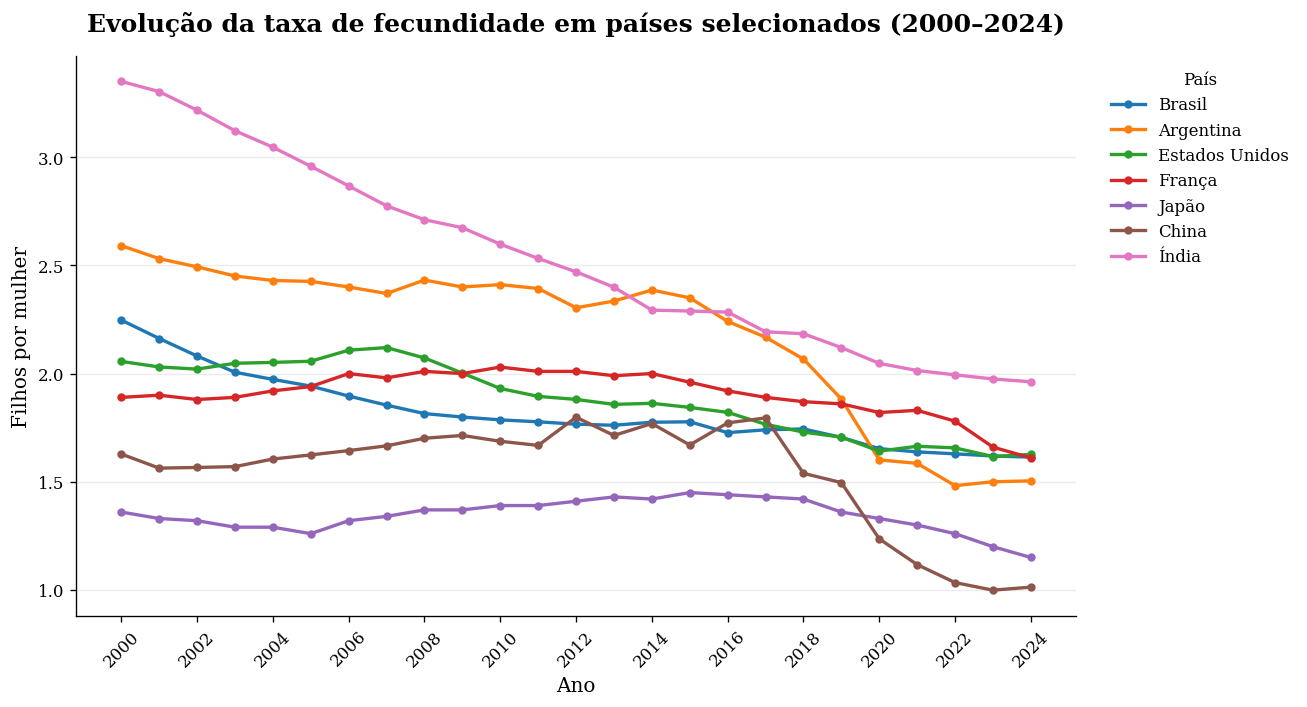

In [60]:
plotar_linhas_paises(
    fertility_filtrado,
    "Evolução da taxa de fecundidade em países selecionados (2000–2024)",
    "Filhos por mulher"
)

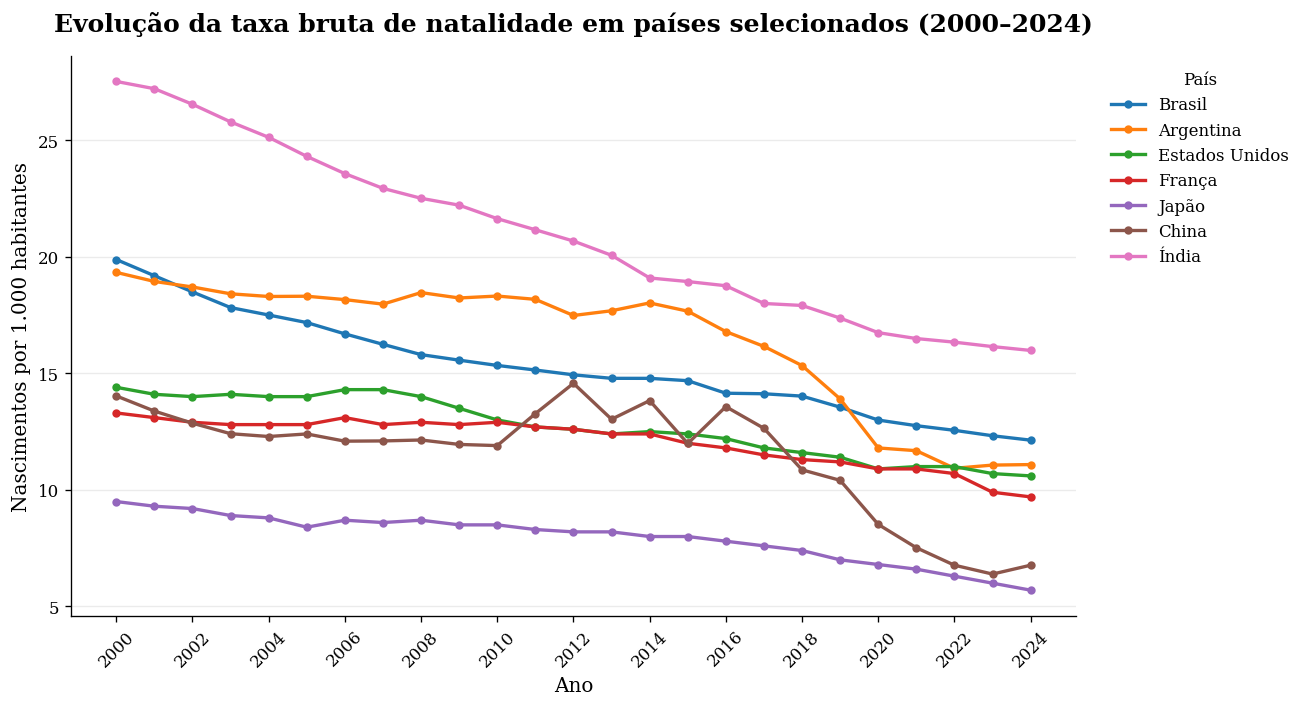

In [61]:
plotar_linhas_paises(
    birth_filtrado,
    "Evolução da taxa bruta de natalidade em países selecionados (2000–2024)",
    "Nascimentos por 1.000 habitantes"
)

In [62]:
def resumo_reducao(df, indicador):
    resumo = df[["Pais", "2000", "2024"]].copy()
    resumo["2000"] = pd.to_numeric(resumo["2000"], errors="coerce")
    resumo["2024"] = pd.to_numeric(resumo["2024"], errors="coerce")
    resumo["Reducao_absoluta"] = resumo["2000"] - resumo["2024"]
    resumo["Reducao_percentual"] = (resumo["Reducao_absoluta"] / resumo["2000"]) * 100
    resumo["Indicador"] = indicador
    return resumo.sort_values("Reducao_percentual", ascending=False)

resumo_fertilidade = resumo_reducao(fertility_filtrado, "Taxa de fecundidade")
resumo_natalidade = resumo_reducao(birth_filtrado, "Taxa bruta de natalidade")

resumo_mundo = pd.concat([resumo_fertilidade, resumo_natalidade], ignore_index=True)
resumo_mundo

,Pais,2000,2024,Reducao_absoluta,Reducao_percentual,Indicador
0,Argentina,2.591,1.5040,1.0870,41.952914,Taxa de fecundidade
1,Índia,3.350,1.9620,1.3880,41.432836,Taxa de fecundidade
2,China,1.628,1.0130,0.6150,37.776413,Taxa de fecundidade
3,Brasil,2.247,1.6140,0.6330,28.170895,Taxa de fecundidade
4,Estados Unidos,2.056,1.6265,0.4295,20.890078,Taxa de fecundidade
5,Japão,1.360,1.1500,0.2100,15.441176,Taxa de fecundidade
6,França,1.890,1.6100,0.2800,14.814815,Taxa de fecundidade
7,China,14.030,6.7700,7.2600,51.746258,Taxa bruta de natalidade
8,Argentina,19.328,11.0860,8.2420,42.642798,Taxa bruta de natalidade
9,Índia,27.518,15.9810,11.5370,41.925285,Taxa bruta de natalidade


In [63]:
!pip install plotly

In [64]:
mapa_mundo = resumo_mundo.copy()

traducao_paises = {
    "Brasil": "Brazil",
    "Argentina": "Argentina",
    "China": "China",
    "Estados Unidos": "United States",
    "França": "France",
    "Índia": "India",
    "Japão": "Japan"
}

mapa_mundo["Pais_mapa"] = mapa_mundo["Pais"].replace(traducao_paises)


In [65]:
import plotly.express as px

mapa_mundo = resumo_mundo.copy()

traducao_paises = {
    "Brasil": "Brazil",
    "Argentina": "Argentina",
    "China": "China",
    "Estados Unidos": "United States",
    "França": "France",
    "Índia": "India",
    "Japão": "Japan"
}

mapa_mundo["Pais_mapa"] = mapa_mundo["Pais"].replace(traducao_paises)

fig = px.choropleth(
    mapa_mundo,
    locations="Pais_mapa",
    locationmode="country names",
    color="Reducao_percentual",
    hover_name="Pais",
    color_continuous_scale="YlOrRd",
    title="Redução percentual da natalidade nos países analisados"
)

fig.add_scattergeo(
    locations=mapa_mundo["Pais_mapa"],
    locationmode="country names",
    text=mapa_mundo["Pais"] + "<br>" + mapa_mundo["Reducao_percentual"].round(1).astype(str) + "%",
    mode="text",
    textfont=dict(size=11, color="black")
)

fig.show()

C:\Users\natal\AppData\Local\Temp\ipykernel_16756\3807001684.py:17: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.

